<a href="https://colab.research.google.com/github/Miguelangel2425/Estancia-de-investigaci-n/blob/main/Adveccion.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Aquí tratamo de resolver la ecuación de advección que describe el transporte de una cantidad escalar (como la densidad o la temperatura) a través de un campo de velocidades:$$\frac{\partial u}{\partial t} + c \frac{\partial u}{\partial x} = 0$$Donde $c$ es la velocidad de advección.

En este modelo, se busca que la solución sea estrictamente periódica en el espacio $[0, L]$, de modo que la señal que sale por un extremo reingrese por el opuesto sin deformaciones numéricas.

Implementamos la estructura de la PINN con la condición inicial:

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt


c = 1.0
L = 1.0
T_max = 2.0


def u0_torch(x):
    return torch.exp(-32 * (x - L/2)**2)


class AdvectionPINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 25), nn.Tanh(),
            nn.Linear(25, 25), nn.Tanh(),
            nn.Linear(25, 25), nn.Tanh(),
            nn.Linear(25, 1)
        )

    def forward(self, x_in):
        t = x_in[:, 1:2]
        x = x_in[:, 0:1]


        x_periodic = torch.cat([
            t,
            torch.cos(2 * np.pi * x / L),
            torch.sin(2 * np.pi * x / L)
        ], dim=1)

        N = self.net(x_periodic)


        return u0_torch(x) + t * N

Implementamos la función de pérdida, pero en este lugar tomamos el logaritmo ya que, según la referencia [2] comentada en el informe, esto mejora la precisión de la optimización.

In [2]:
# 4. Función de pérdida con mejora logarítmica
def physics_loss(model, points):
    points.requires_grad_(True)
    u = model(points)

    grads = torch.autograd.grad(u, points, torch.ones_like(u), create_graph=True)[0]
    u_x = grads[:, 0:1]
    u_t = grads[:, 1:2]

    f = u_t + c * u_x
    mse_f = torch.mean(f**2)

    return torch.log(mse_f + 1e-10)


model = AdvectionPINN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_history = []
for epoch in range(10000):
    optimizer.zero_grad()


    x_f = torch.rand(10000, 1) * L
    t_f = torch.rand(10000, 1) * T_max
    train_points = torch.cat([x_f, t_f], dim=1)

    loss = physics_loss(model, train_points)
    loss.backward()
    optimizer.step()
    real_loss = torch.exp(loss).detach().item()
    loss_history.append(real_loss)
    if epoch % 500 == 0:
        print(f"Epoch {epoch}, Log-Loss: {loss.item():.4f}")


Epoch 0, Log-Loss: 2.0174
Epoch 500, Log-Loss: -1.9463
Epoch 1000, Log-Loss: -2.7591
Epoch 1500, Log-Loss: -2.8965
Epoch 2000, Log-Loss: -3.0437
Epoch 2500, Log-Loss: -3.1060
Epoch 3000, Log-Loss: -3.1950
Epoch 3500, Log-Loss: -3.2485
Epoch 4000, Log-Loss: -3.3529
Epoch 4500, Log-Loss: -3.4431
Epoch 5000, Log-Loss: -3.4772
Epoch 5500, Log-Loss: -3.5918
Epoch 6000, Log-Loss: -3.6983
Epoch 6500, Log-Loss: -3.8719
Epoch 7000, Log-Loss: -3.9319
Epoch 7500, Log-Loss: -4.0686
Epoch 8000, Log-Loss: -4.2404
Epoch 8500, Log-Loss: -4.4128
Epoch 9000, Log-Loss: -4.5651
Epoch 9500, Log-Loss: -4.6798


Graficamos la solución obtenida y la evolución de la función de pérdida.

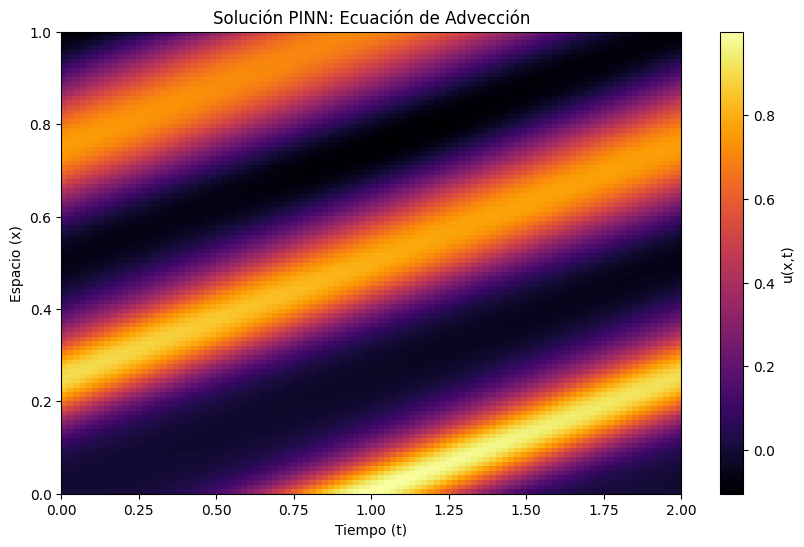

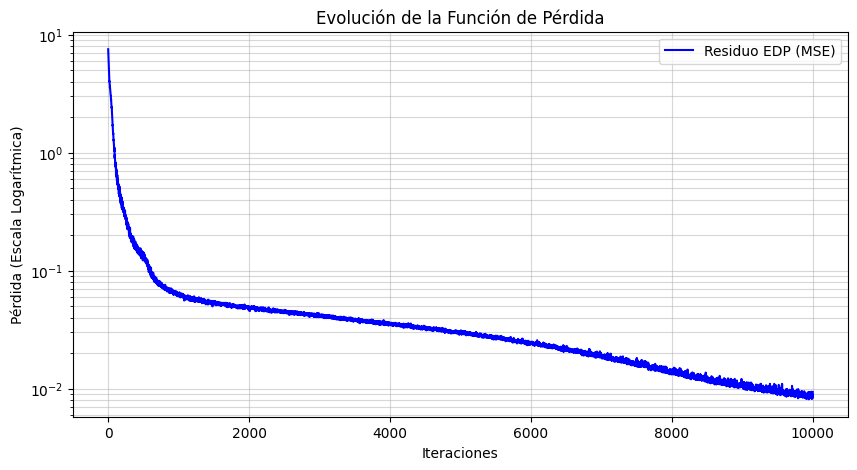

In [3]:
def plot_solution(model, L=1.0, T=2.0, res=100):

    x = np.linspace(0, L, res)
    t = np.linspace(0, T, res)
    X, T_grid = np.meshgrid(x, t)


    X_star = np.hstack((X.flatten()[:, None], T_grid.flatten()[:, None]))
    X_star_tensor = torch.tensor(X_star, dtype=torch.float32)


    with torch.no_grad():
        u_pred = model(X_star_tensor).numpy().reshape(res, res)


    plt.figure(figsize=(10, 6))
    plt.imshow(u_pred, extent=[0, T, 0, L], origin='lower', aspect='auto', cmap='inferno')
    plt.colorbar(label='u(x,t)')
    plt.title("Solución PINN: Ecuación de Advección")
    plt.xlabel("Tiempo (t)")
    plt.ylabel("Espacio (x)")
    plt.show()


plot_solution(model)

def plot_loss_evolution(history):
    plt.figure(figsize=(10, 5))
    plt.plot(history, color='blue', label='Residuo EDP (MSE)')
    plt.yscale('log')  # Escala logarítmica para ver la convergencia clara [cite: 312]
    plt.title("Evolución de la Función de Pérdida")
    plt.xlabel("Iteraciones")
    plt.ylabel("Pérdida (Escala Logarítmica)")
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    plt.show()


plot_loss_evolution(loss_history)